In [21]:
import tables
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2


In [22]:
a = tables.open_file("/data/cta/users-ifae/summer_students/agl/try_2/chis_all.h5")

In [23]:
a.root.chis2.results

/chis2/results (Table(np.int64(3505),)) np.str_('Combined chi2 results')
  description := {
  "check_index": Int32Col(shape=(), dflt=np.int32(0), pos=0),
  "chi2": Float64Col(shape=(), dflt=np.float64(0.0), pos=1),
  "dof": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "run": Int32Col(shape=(), dflt=np.int32(0), pos=3)}
  byteorder := 'little'
  chunkshape := (np.int64(3276),)

[]

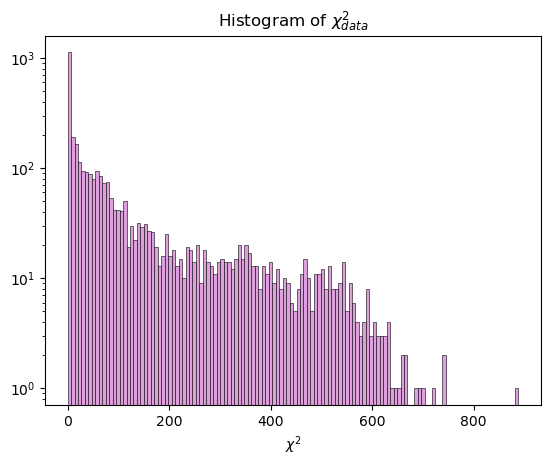

In [24]:
chi2_data = a.root.chis2.results.col('chi2')

plt.hist(chi2_data, bins=130, color='plum',  edgecolor='black', linewidth=0.4)
plt.xlabel(r'$ \chi ^2$')
plt.title(r'Histogram of $ \chi ^2_{ data}$')
plt.yscale('log')
plt.plot()

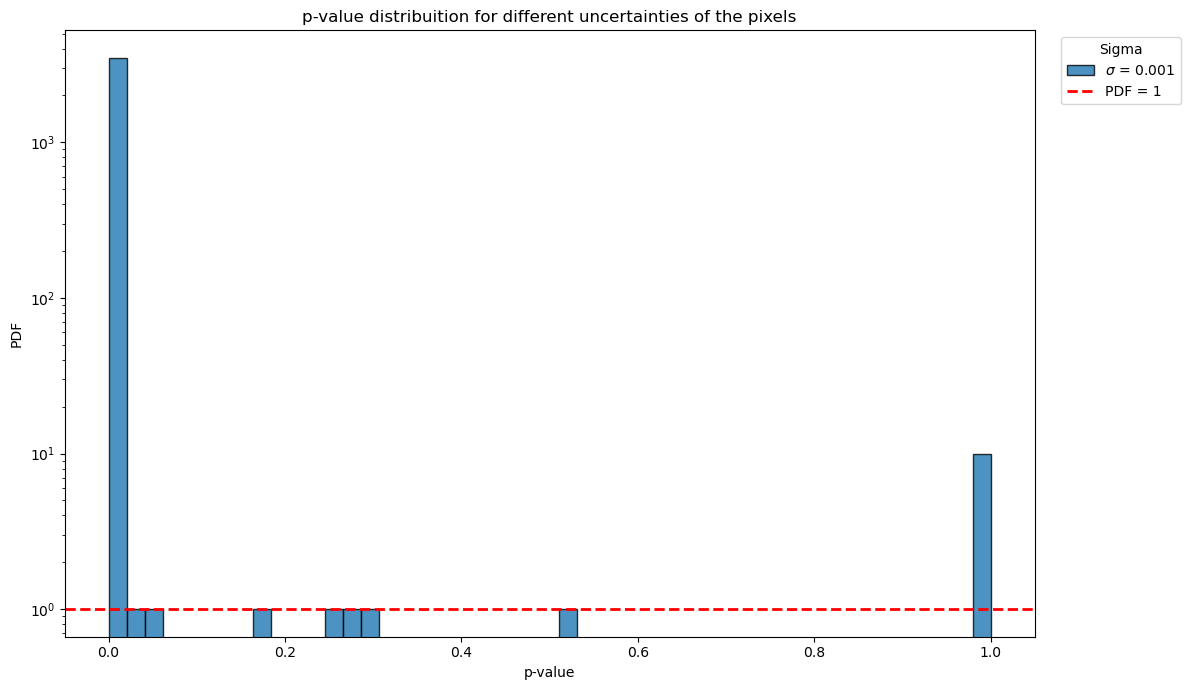

In [49]:
#sigma_pixels = np.linspace(0.001, 0.2, 10)[:, np.newaxis]
sigma_pixels = 0.001
sigma_pixel_o = (28)*np.tan(np.radians(0.05))
dof = a.root.chis2.results.col('dof')


chi2_data_new = (sigma_pixel_o / sigma_pixels)**2 * chi2_data
p_values = 1 - chi2.cdf(chi2_data_new, dof)


plt.figure(figsize=(12, 7))
bins = np.linspace(0, 1, 50)  

plt.hist(p_values.T, bins=bins, label=labels, edgecolor='black', alpha=0.8)


plt.xlabel('p-value')
plt.ylabel('PDF')
plt.yscale('log')
plt.title('p-value distribuition for different uncertainties of the pixels')

plt.axhline(y=1, color='red', linestyle='--', lw=2, label='PDF = 1')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Sigma')
plt.tight_layout()
plt.show()